In [1]:
%%HTML
<script src="require.js"></script>

In [2]:
from IPython.display import HTML, display, Markdown, Image

HTML(
    '<script src="https://cdnjs.cloudflare.com/ajax/libs/jquery/2.0.3/'
    'jquery.min.js"></script>'
    '<script>'
    'code_show=true;'
    'function code_toggle(){'
    'if(code_show){'
    "$('div.jp-CodeCell > div.jp-Cell-inputWrapper').hide();"
    '}else{'
    "$('div.jp-CodeCell > div.jp-Cell-inputWrapper').show();"
    '}'
    'code_show=!code_show;'
    '}'
    '$(document).ready(code_toggle);'
    '</script>'
    '<form action="javascript:code_toggle()">'
    '<input type="submit" value="Click here to toggle on/off the raw code.">'
    '</form>'
)

In [2]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql.functions import ( 
 col, to_date,  lit, mean as _mean, date_format)
from typing import List, Dict, Tuple
import glob
import gzip
from functools import reduce
import re # Added for the regex file read helper



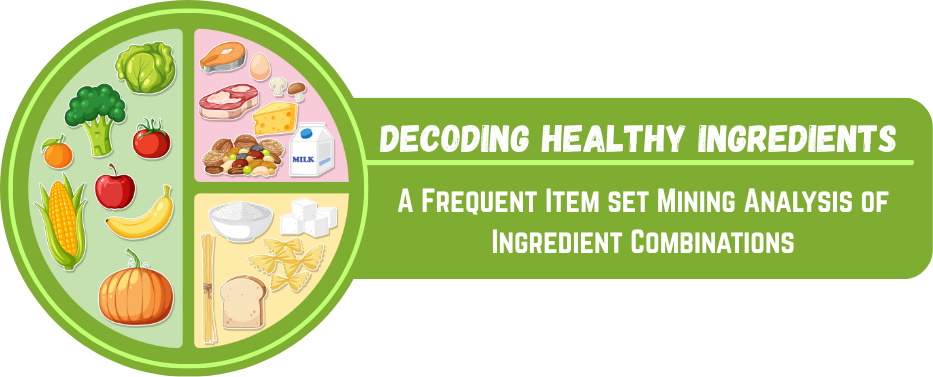


<a id='ExecSum'></a>
<h1 style="color:#ffffff; background-color:#2E7D32; border: 1px solid #ffffff; padding: 10px 0;">
I. Abstract
</h1>


<a id='Introduction'></a>
<h1 style="color:#ffffff; background-color:#2E7D32; border: 1px solid #ffffff; padding: 10px 0;">II. Introduction</h1>

The Covid-19 Pandemic caused a global collapse in travel and hospitality as international boards began closing and domestic travel was restricted. Studies have shown that the pandemic created significant economic damage to the tourism industry which relied heavily on travel and hospitality (Naveed et al. 2024). In cities such as New York, Los Angeles and Austin Texas this is more relevant than ever. 

Within New York city, a research paper during the pandemic on the city’s tourism found that the city was vulnerable because of its status as a high volume international destination. Because of COVID-19 and the tightening restriction to travel arrivals and mobility led to steep declines in the Economy of hospitality activity (Naveed et al. 2024).
Los Angeles on the other hand depended heavily on tourism because of its connection to the entertainment industry. When the pandemic stopped film production and restricted movement, the local entertainment industry suffered losses with economic analyses showing significant job reductions and revenue declines across LA’s entertainment (Beacon Economics, “The Impact of COVID-19 on Los Angeles’ Entertainment Industry”).
Austin’s economy on the other hand was focused around major gatherings and events. When COVID-19 came into events and large social gatherings were halted. With this Austin experienced sharp drops in visitors and spending. A survey on Austin showed economic stress on the local economy and a decline in tourism (Filieri et al. 2023).
Airbnb and the Short-Term Rental Market

Because Airbnb operates right in the middle of tourism and urban mobility, its data base offers a way to track how the pandemic reshaped the rental markets. Research on Airbnb during COVID-19 shows significant shifts in booking behavior and pricing patterns with many markets experiencing reduced stays and altered consumer preferences(Fox et al. 2023). By analyzing these changes in prices, multi-property host activity, and listing availability before, during, and after the pandemic, this study aims to measure how New York, Los Angeles, and Austin each responded and how their markets recovered.


<a id='Problem Statement'></a>
<h1 style="color:#ffffff; background-color:#2E7D32; border: 1px solid #ffffff; padding: 10px 0;">III.Problem Statement</h1>

This project aims to study how the COVID-19 crisis influenced key operational indicators in Airbnb markets across New York, Austin, and Los Angeles. Specifically, it evaluates three major impacts:
1. Changes in rent prices over time,
2. Changes in the number of listings controlled by multi-property hosts, and
3. Changes in listing availability throughout the pandemic timeline.

#### The goal is to quantify how the pandemic reshaped host behavior, market supply, and consumer demand across these three major U.S. cities.


<a id='Methodology'></a>
<h1 style="color:#ffffff; background-color:#2E7D32; border: 1px solid #ffffff; padding: 10px 0;">IV. METHODOLOGY</h1>

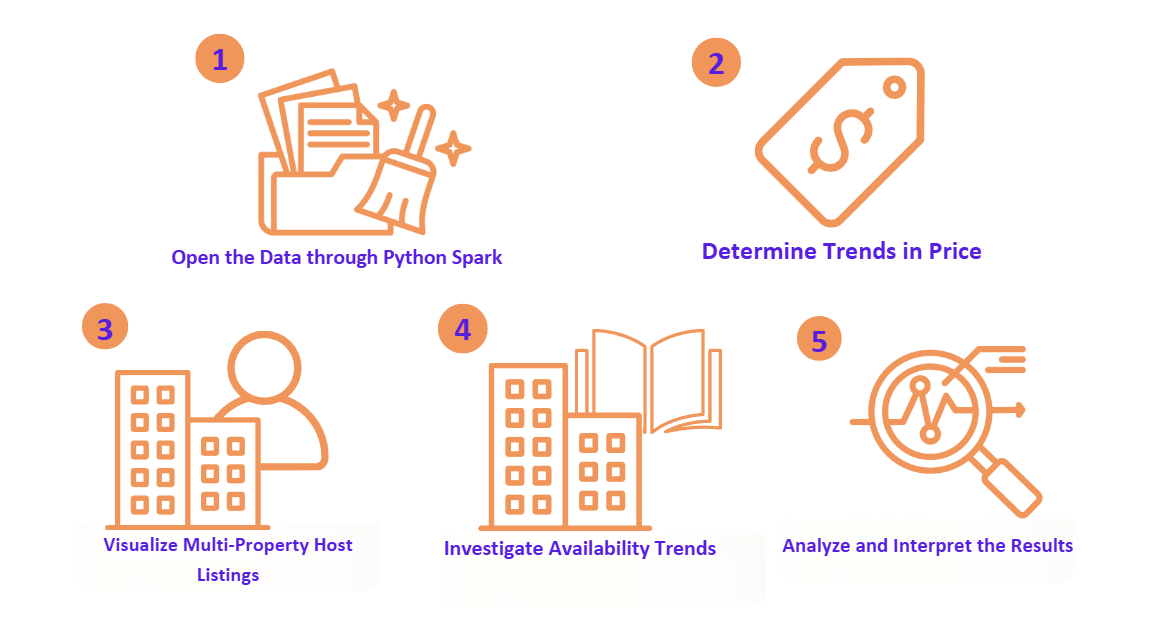

<left><span style="font-size:14px"><b>Figure 1. </b>Methodology</span></left>



3.1 Data Processing and Cleaning

- Load all CSV files into Spark DataFrames to handle large file sizes efficiently.
- Exclude corrupted CSV files that fail to load


3.2 Price Analysis

To see how the price of listings change over time,the `price` of each listing is separated into different csv date files, so the average of each date is calculated and graphed.


3.3 Multi-Property Host Analysis

To see the behavior of multi-property hosts, we can see the number of properties the hosts have, then graph to show how the average `calculated_host_listings_count` change through the years.


3.4 Availability Analysis

To see how listings change whether they are available for renting, we create graphs to track `availability_365` trends.


3.5 Interpret Results

Insights and business recommendations are then made after creating all the descriptive analytics


<a id='Collection'></a>
<h1 style="color:#ffffff; background-color:#2E7D32; border: 1px solid #ffffff; padding: 10px 0;">IV. Collect and Preprocess the Data</h1>

The data collection section involves three key steps:
1. Identifying the data source;
2. Collecting and storing the data as a CSV; and
3. Describing the data.

<h2 style="color:#ff9a00">A. Data Source</h2>

The team utilized the InsideAirBnB dataset, which is publicly available through the ‘jojie-collected’ repository in the /mnt/data/public directory maintained by the Asian institute of Management. The datasets, located at `/mnt/data/public/insideairbnb/data.insideairbnb.com/`, contains various recipes and reviews.



<h2 style="color:#ff9a00">B. Data Collection and Database Creation</h2>

To gather the listings data, we narrowed the scope to the years `2019`-`2021` and iterated through the file paths

`united-states/ny/new-york-city`

`united-states/tx/austin`

`united-states/ca/los-angeles`

In [ ]:
# --- CONFIGURATION ---
COLUMNS = "price","calculated_host_listings_count","availability_365"
BASE_DIR = "" 

PATH_PREFIX = "mnt/data/public/insideairbnb/data.insideairbnb.com/"

START_DATE = "2019-01-01"
END_DATE = "2021-12-31"


CITY_CONFIGS = [
    {
        "label": "new-york-city",
        "root_path": f"{PATH_PREFIX}united-states/ny/new-york-city", 
        "regex_key": "united-states/ny/new-york-city",               
    },
    {
        "label": "austin",
        "root_path": f"{PATH_PREFIX}united-states/tx/austin",
        "regex_key": "united-states/tx/austin",
    },
    {
        "label": "los-angeles",
        "root_path": f"{PATH_PREFIX}united-states/ca/los-angeles",
        "regex_key": "united-states/ca/los-angeles",
    },
]

<h2 style="color:#ff9a00">C. Data Description</h2>

The following features were used and considered relevant for this report:

Data Source and Features



<table>
  <thead>
    <tr>
      <th>Feature</th>
      <th>Description</th>
      <th>Data Type</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>host_id</td>
      <td>Unique identifier of host</td>
      <td>integer</td>
    </tr>
    <tr>
      <td>price</td>
      <td>daily price in local currency. Note, $ sign may be used despite locale</td>
      <td>currency(integer)</td>
    </tr>
    <tr>
      <td>calculated_host_listings_count</td>
      <td>The number of listings the host has in the current scrape, in the city/region geography.</td>
      <td>integer</td>
    </tr>
    <tr>
      <td>availability_365</td>
      <td>availability_x. The availability of the listing x days in the future as determined by the calendar. Note a listing may be available because it has been booked by a guest or blocked by the host.</td>
      <td>integer</td>
    </tr>
  </tbody>
</table>

Table 1. Dataset: InsideAirBnB (listings.csv) for New York, Austin, and Los Angeles.

<h2 style="color:#ff9a00">D. Preprocess the Data</h2>

We open the compressed csv's using python, extract the target column, date, then convert it to Spark DataFrames. If the csv file is corrupted or unable to be read, it is then skipped

In [ ]:
def read_file_to_spark_df(spark, filepath: str, target_column: str, date_pattern: str):
    """
    Read a single CSV file using Python, 
    then convert to Spark DataFrame for distributed processing.
    Returns None if file can't be read or column doesn't exist.
    """
    # Extract date from filepath
    match = re.search(date_pattern, filepath)
    if not match:
        return None
    file_date = match.group(1)
    
    # Try reading with gzip
    try:
        with gzip.open(filepath, 'rt', encoding='utf-8', errors='ignore') as f:
            pdf = pd.read_csv(f, usecols=[target_column], dtype={target_column: float})
    except:
        # Try as plain CSV
        try:
            pdf = pd.read_csv(filepath, usecols=[target_column], dtype={target_column: float})
        except:
            return None
    
    if target_column not in pdf.columns:
        return None
    
    # Add date column
    pdf["date"] = file_date
    
    # Convert to Spark DataFrame
    return spark.createDataFrame(pdf)

Then for each csv, the daily mean is collected, with null values being ignored in the calculation. After that, since there are csv files that exist in the same month, they are both averaged to find the monthly average over time.

In [ ]:
# -------------------------------------------------------------
# Per-city: collect daily means using Spark
# -------------------------------------------------------------
def collect_daily_mean_spark(
    spark: SparkSession, city_config: Dict, column: str, base_dir: str, start_date: str, end_date: str
) -> pd.DataFrame:
    """
    Reads data for a single city, calculates the daily mean for the column, 
    and filters by the date range using Spark.
    
    Returns a Pandas DataFrame of daily means.
    """
    label = city_config["label"]
    # UPDATED: Use the new root_path and regex_key
    root_path = city_config["root_path"]
    regex_key = city_config["regex_key"]
    daily_mean_col = f"{column}_mean"
    
    # --- 1. Read Files ---
    # UPDATED: Glob pattern uses root_path
    glob_pattern = f"{base_dir}/{root_path}/*/visualisations/listings.csv"
    
    try:
        # Spark reads all matching files
        df = (
            spark.read
            .option("header", True)
            .option("inferSchema", True)
            .csv(glob_pattern)
            .withColumn("source_file", input_file_name())
        )
    except Exception as e:
        print(f"[{label}] Error reading data: {e}")
        return pd.DataFrame()

    if df.rdd.isEmpty():
        print(f"[{label}] No data in files.")
        return pd.DataFrame()

    # --- 2. Extract Date and Filter ---
    # UPDATED: Regex uses regex_key
    # The regex key is the full directory path segment preceding the date folder.
    date_pattern = rf"/{regex_key}/(\d{{4}}-\d{{2}}-\d{{2}})/visualisations/listings.csv"
    
    df = (
        df.withColumn("date_str", regexp_extract(col("source_file"), date_pattern, 1))
          .withColumn("date", to_date(col("date_str"), "yyyy-MM-dd"))
          .drop("date_str")
    )
    
    # Drop rows missing date or the target column
    df = df.dropna(subset=["date", column])

    # Date range filter
    df = df.filter(
        (col("date") >= lit(start_date)) & 
        (col("date") <= lit(end_date))
    )
    
    # Safely cast the price column to double and filter for positive values
    df = df.withColumn(column, expr(f"try_cast({column} AS DOUBLE)"))
    df = df.filter(col(column) > 0).filter(col(column).isNotNull())


    # --- 3. Aggregate Daily Mean ---
    daily = (
        df.groupBy("date")
          .agg(_mean(column).alias(daily_mean_col))
          .withColumn("city_label", lit(label))
          .withColumn("month", date_format(col("date"), "yyyy-MM"))
          .orderBy("date")
    )
    
    # Return the final daily aggregated result as a Pandas DataFrame
    return daily.toPandas()


# -------------------------------------------------------------
# Per-city: aggregate daily → monthly (mean of daily means) using Spark
# -------------------------------------------------------------
def aggregate_to_months_mean_spark(daily_df: pd.DataFrame, column: str) -> pd.DataFrame:
    """
    Aggregates a Pandas DataFrame of daily means into a monthly mean 
    using Spark for efficient grouping.
    """
    if daily_df.empty:
        return pd.DataFrame()

    daily_mean_col = f"{column}_mean"
    monthly_mean_col = f"{column}_mean_month"

    # Create a Spark DataFrame from the Pandas DataFrame
    spark_df = spark.createDataFrame(daily_df)
    
    # Group by city and month, then calculate the mean of the daily means
    month_df_spark = (
        spark_df.groupBy("city_label", "month")
        .agg(_mean(daily_mean_col).alias(monthly_mean_col))
        .sort("city_label", "month")
        .drop("city_label") # Drop before conversion to match original function output
    )
    
    # Convert the result back to Pandas
    month_df = month_df_spark.toPandas()
    return month_df

<a id='Exploration'></a>
<h1 style="color:#ffffff; background-color:#2E7D32; border: 1px solid #ffffff; padding: 10px 0;">V. Exploratory Data Analysis</h1>

In [ ]:
%run Spark_availability.ipynb
%run Spark_host_listing.ipynb
%run Spark_price.ipynb

For `host_listing` and `availability`, we create a line graph and bar graph showing the trend monthly and yearly, but for `price` we kept it as monthly.

In [ ]:
# Plot multiple cities: monthly average availability
def plot_monthly(city_results: list, column: str, outfile="images/host_monthly_mean.png"):
    plt.figure(figsize=(12, 6))
    IMPORTANT_DATES = [
        "2020-03-11",  # WHO pandemic declaration
        "2021-01-01",
    ]
    for d in IMPORTANT_DATES:
        dt = pd.to_datetime(d)
        plt.axvline(dt, linestyle="--", linewidth=1)
        plt.text(dt, 0, d, rotation=90, va="bottom", fontsize=8)
    
    # Iterate over list of tuples: (label, dataframe)
    for label, data in city_results:
        # Handle both cases: data is a DataFrame or a dict with 'monthly' key
        if isinstance(data, dict):
            month_df = data.get("monthly")
        else:
            month_df = data
        
        if month_df is None or month_df.empty:
            continue
        df = month_df.copy()
        
        # Handle both 'month' and 'date' column names
        date_col = 'month' if 'month' in df.columns else 'date'
        df["month_dt"] = pd.to_datetime(df[date_col])
        col = f"{column}_mean_month"
        plt.plot(df["month_dt"], df[col], marker="o", label=label)
    
    plt.xlabel("Month")
    plt.ylabel("Average Host Listing Count")
    plt.title("Monthly Average calculated_host_listings_count by City")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(outfile, dpi=150)
    plt.show()
    print(f"Saved figure to {outfile}")


# Plot multiple cities: yearly average availability
def plot_yearly(city_results: list, column: str, outfile="images/host_yearly_mean.png"):
    """
    Bar chart of yearly average availability (2019, 2020, 2021)
    with numerical labels on each bar.
    """
    all_rows = []
    col_name = f"{column}_mean_month"
    
    # Iterate over list of tuples: (label, dataframe)
    for label, data in city_results:
        # Handle both cases: data is a DataFrame or a dict with 'monthly' key
        if isinstance(data, dict):
            month_df = data.get("monthly")
        else:
            month_df = data
        
        if month_df is None or month_df.empty:
            continue
        df = month_df.copy()
        
        # Handle both 'month' and 'date' column names
        date_col = 'month' if 'month' in df.columns else 'date'
        df["year"] = df[date_col].str.slice(0, 4)
        
        yearly = (
            df.groupby("year")[col_name]
            .mean()
            .reindex(["2019", "2020", "2021"])
        )
        all_rows.append((label, yearly))
    
    # Plot
    plt.figure(figsize=(10, 6))
    years = ["2019", "2020", "2021"]
    x = range(len(years))
    bar_width = 0.25
    offset_index = 0
    
    for label, yearly_series in all_rows:
        y_vals = yearly_series.values
        x_positions = [i + offset_index * bar_width for i in x]
        bars = plt.bar(x_positions, y_vals, width=bar_width, label=label)
        
        for bar, value in zip(bars, y_vals):
            if pd.isna(value):
                continue
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f"{value:.1f}",
                ha="center",
                va="bottom",
                fontsize=9
            )
        offset_index += 1
    
    plt.xticks([i + bar_width * (len(all_rows) - 1) / 2 for i in x], years)
    plt.ylabel("Avg Host Listings Count")
    plt.title("Yearly Average calculated_host_listings_count (2019–2021)")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(outfile, dpi=150)
    plt.show()
    print(f"Saved bar chart to {outfile}")

<a id='Apply FIM'></a>
<h1 style="color:#ffffff; background-color:#2E7D32; border: 1px solid #ffffff; padding: 10px 0;">VII. Compare, Analyze, and Interpret the Results</h1>

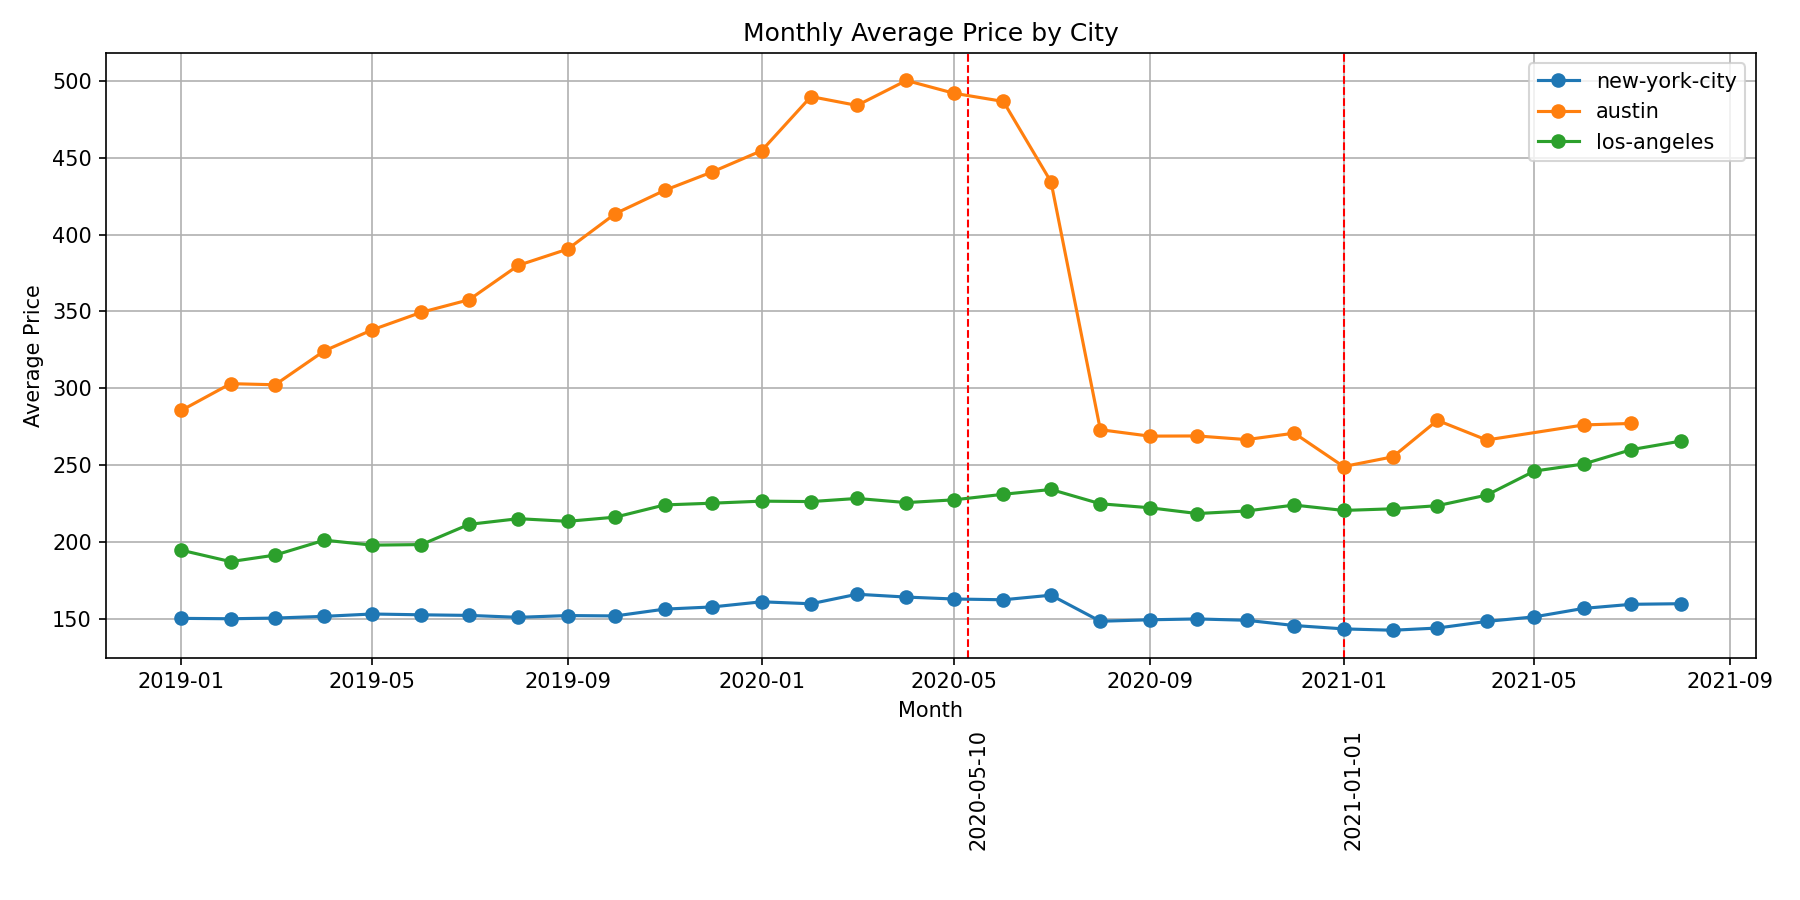

<left><span style="font-size:14px"><b>Figure 2. </b>Monthly Average Price</span></left>

As seen in Figure 2 there is a sharp decline in prices in Austin Texas, this can be attributed to the city’s heavy dependence on large gatherings and event-driven tourism. As noted, the foundation to Austin's local economy is festivals, conventions, and live entertainment, all of which were halted during the COVID-19. With these events gone, so did the majority of Austin’s visitor traffic which forced hosts to cut prices dramatically to attract the few remaining renters, resulting in the steep drop shown in the graph.

In contrast, New York City and Los Angeles did not experience this drop in prices because their short-term rental markets. Despite suffering a major drop in tourism, both cities have large resident populations and continued local mobility, creating a baseline level of occupancy even during the pandemic. As supported in the introduction of the report, New York maintained activity due to internal relocations and essential workers, while Los Angeles was cushioned by its large domestic population and diverse economic base. This helped both cities stabilize prices, whereas Austin that has no comparable local fallback demand experienced the most severe pricing shock.


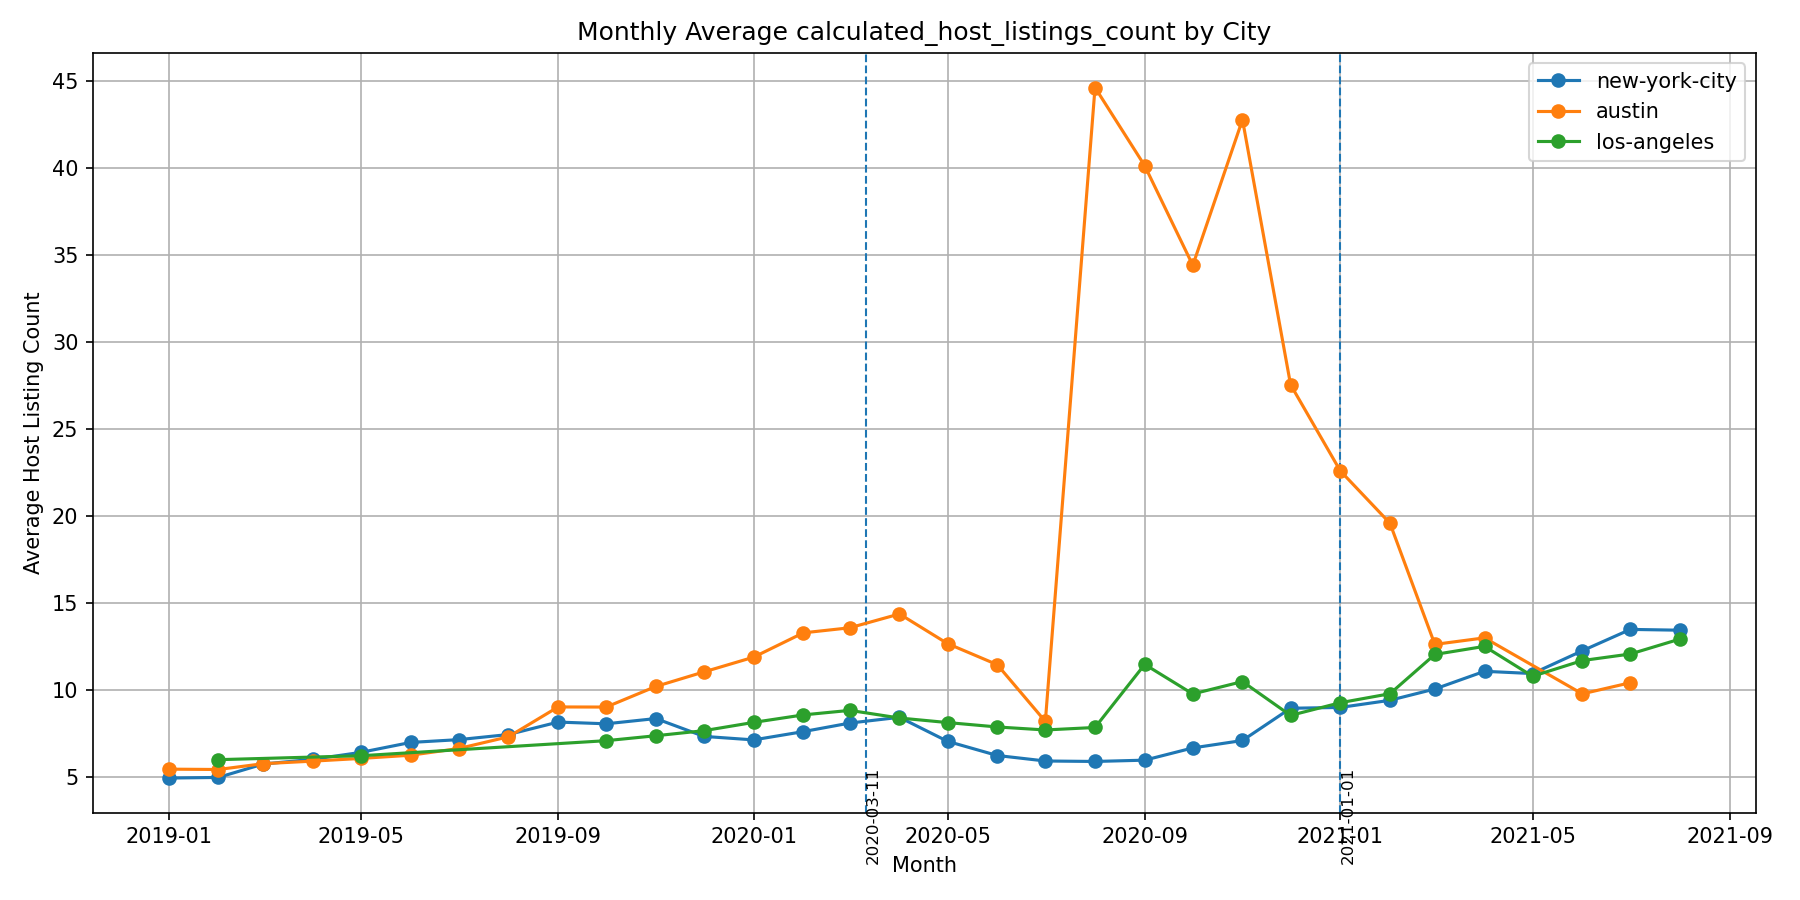

<left><span style="font-size:14px"><b>Figure 3. </b>Monthly Average # of listings owned</span></left>

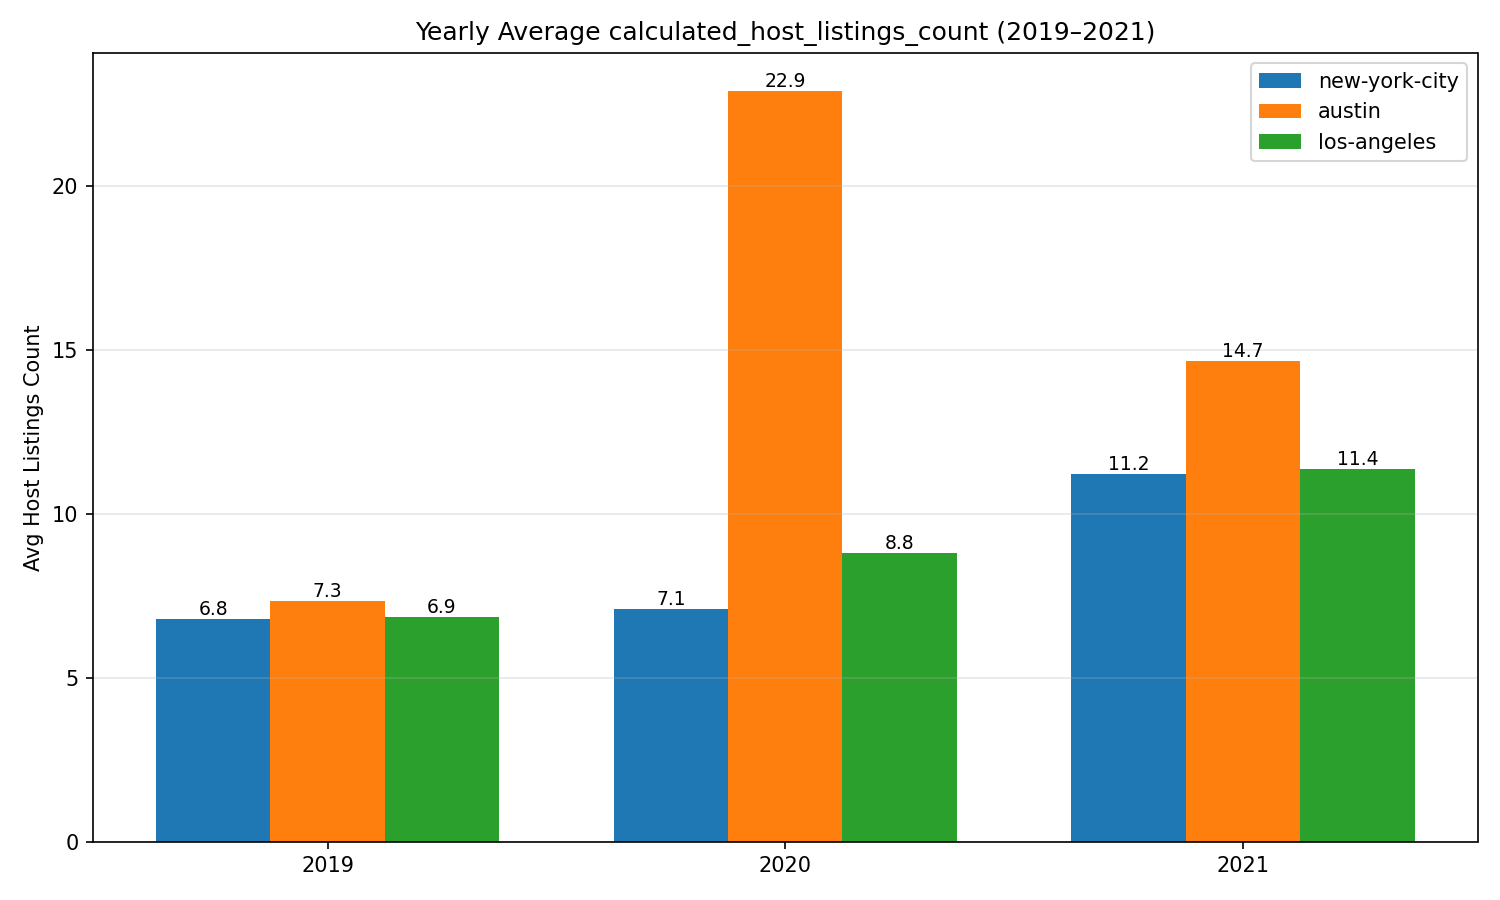

<left><span style="font-size:14px"><b>Figure 4. </b>Yearly Average # of listings owned</span></left>

In Figure 3, In Austin, the average calculated_host_listings_count per host rose sharply in mid-2020, jumping from single-digits to more than forty listings per host before falling back down the following year. This pattern reflects a temporary consolidation shock. As tourism and event-driven demand in Austin collapsed, many small and casual hosts exited the platform, leaving a smaller pool of professional multi-property operators controlling a large share of remaining listings. With fewer active hosts but similar or only slowly adjusting listing counts, the average number of listings per host inflated dramatically.
By comparison, New York City and Los Angeles show relatively smooth, gradual increases in average host listing counts throughout the 2019–2021 period. This suggests a more diversified market where multi-property hosting was already established and less dependent on a narrow tourism or events niche. Even as travel restrictions hit, both cities retained a broader base of active hosts and more stable demand linked to dense urban populations and long-term housing pressure, which kept the host structure from swinging wildly. Combined with the earlier price trends, these results indicate that Austin’s Airbnb market was structurally more fragile: when tourism disappeared, not only did prices collapse, but market participation also concentrated briefly in the hands of a few large operators before normalizing again as conditions improved.


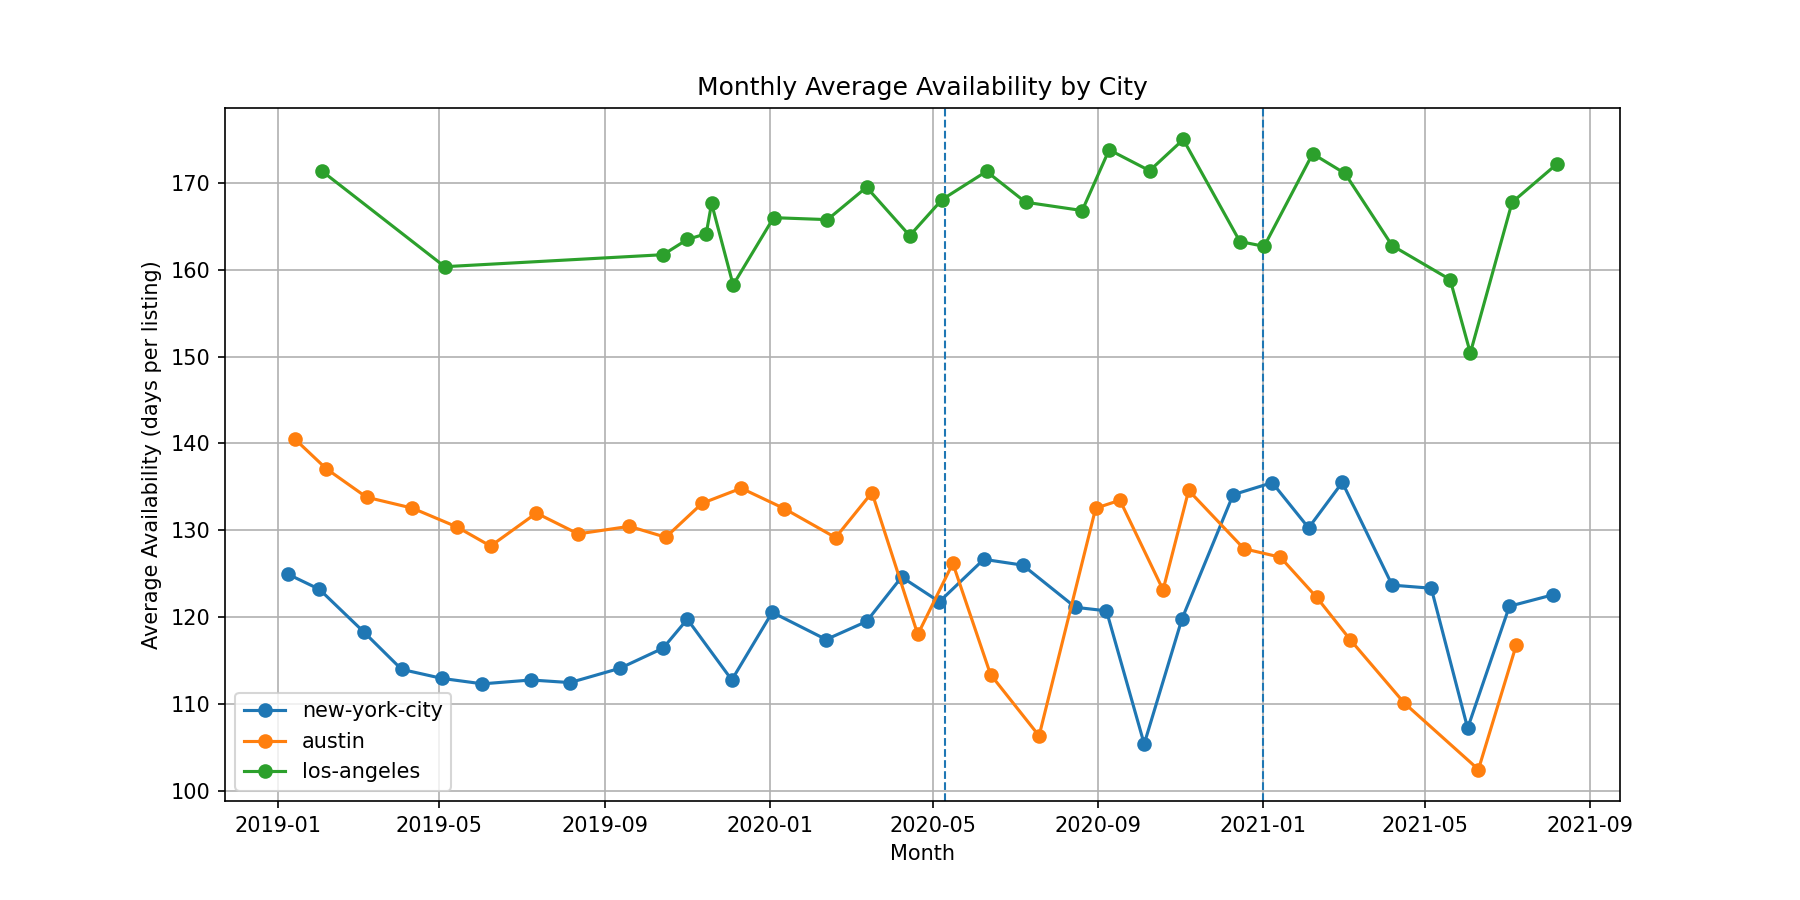

<left><span style="font-size:14px"><b>Figure 5. </b>Monthly Average availability of listings</span></left>

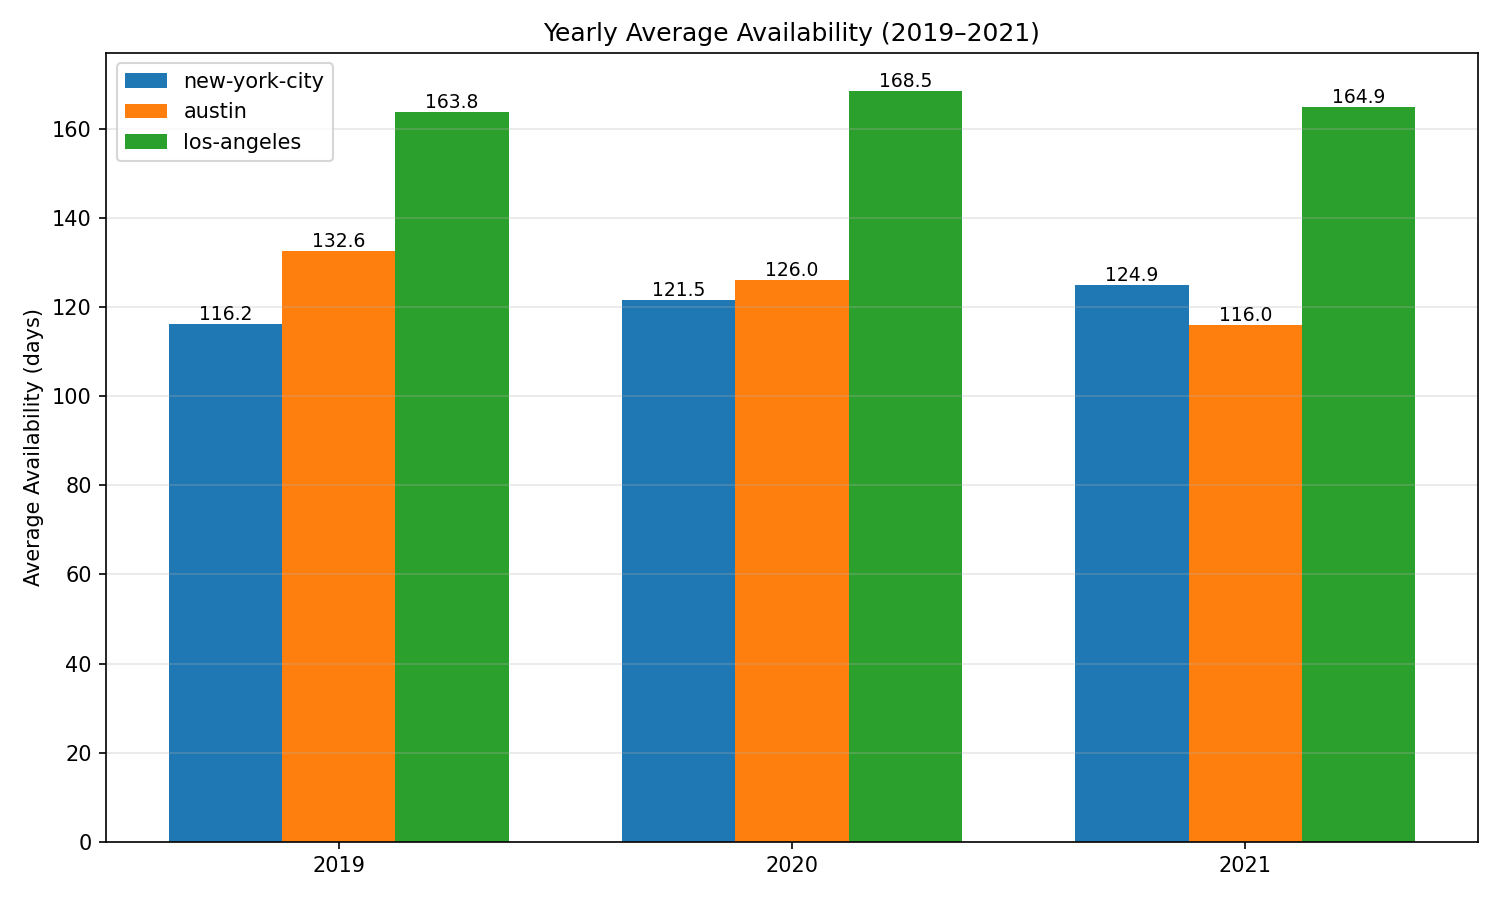

<left><span style="font-size:14px"><b>Figure 5. </b>Yearly Average availability of listings</span></left>

<a id='Recommendation'></a>
<h1 style="color:#ffffff; background-color:#2E7D32; border: 1px solid #ffffff; padding: 10px 0;">VIII. RECOMMENDATION & LIMITATIONS</h1>

<a id='Limitations'></a>
<h2 style="color:#ff9a00">A. Limitations of the Study</h2>

<a id='Recommendation2'></a>
<h2 style="color:#ff9a00">B. Recommendation</h2>

<a id='Conclusion'></a>
<h1 style="color:#ffffff; background-color:#2E7D32; border: 1px solid #ffffff; padding: 10px 0;">IX. CONCLUSION</h1>

<a id='References'></a>
<h1 style="color:#ffffff; background-color:#2E7D32; border: 1px solid #ffffff; padding: 10px 0;">ACKNOWLEDGEMENTS</h1>

<a id='References'></a>
<h1 style="color:#ffffff; background-color:#2E7D32; border: 1px solid #ffffff; padding: 10px 0;">REFERENCES</h1>

<ul style="list-style-type:none; padding-left:0;">
  <li style="margin-bottom:1em; text-indent:-1.5em; padding-left:1.5em;">
    American Heart Association. (2024, August 23). Dietary Fats. Dietary Fats. <br>
    Retrieved November 11, 2025, from <a href="https://www.heart.org/en/healthy-living/healthy-eating/eat-smart/fats/dietary-fats">https://www.heart.org/en/healthy-living/healthy-eating/eat-smart/fats/dietary-fats</a>
  </li>
  <li style="margin-bottom:1em; text-indent:-1.5em; padding-left:1.5em;">
    Das, M., Das, A. A comprehensive review on strategies for replacing saturated fats in bakery products. Discov Food 4, 156 (2024). <br>
    <a href="https://doi.org/10.1007/s44187-024-00240-2">https://doi.org/10.1007/s44187-024-00240-2</a>
  </li>

  <li style="margin-bottom:1em; text-indent:-1.5em; padding-left:1.5em;">
    Dietary Guidelines for Americans. (2025). Make Every Bite Count With the Dietary Guidelines. <br>
    Retrieved November 11, 2025, from <a href="https://www.dietaryguidelines.gov/sites/default/files/2020-12/Dietary_Guidelines_for_Americans_2020-2025.pdf">https://www.dietaryguidelines.gov/sites/default/files/2020-12/Dietary_Guidelines_for_Americans_2020-2025.pdf</a>
  </li>

  <li style="margin-bottom:1em; text-indent:-1.5em; padding-left:1.5em;">
     Food.com Recipes and Interactions. (2019, November 8). Kaggle. <br>
    Retrieved November 11, 2025, from <a href="https://www.kaggle.com/datasets/shuyangli94/food-com-recipes-and-user-interactions">https://www.kaggle.com/datasets/shuyangli94/food-com-recipes-and-user-interactions</a>
  </li>

  
  <li style="margin-bottom:1em; text-indent:-1.5em; padding-left:1.5em;">
  Ranjit, N., Macias, S., & Hoelscher, D. (2020). Factors related to poor diet quality in food insecure populations. <br>
  PubMed, 10(6), 1297–1305. <br>
  <a href="https://doi.org/10.1093/tbm/ibaa028">https://doi.org/10.1093/tbm/ibaa028</a>
  </li>

  <li style="margin-bottom:1em; text-indent:-1.5em; padding-left:1.5em;">
    Stein, E. C., Stowers, K. C., McCabe, M. L., White, M. A., & Schwartz, M. B. (2019). Ingredient bundles and recipe tastings in food pantries: a pilot study to increase the selection of healthy foods. Public Health Nutrition, 22(09), 1717–1722. <br>
    <a href="https://doi.org/10.1017/s1368980019000259">https://doi.org/10.1017/s1368980019000259</a>
  </li>


</ul>


***
**END**